# Housing Affordability — Data Centers & Residential Quality of Life

Measures housing cost trends across four data center case study counties
using Zillow Research data (2000–present) and Census ACS income data.

Metrics:
- **Median home value (ZHVI)** — Zillow Home Value Index, county-level single-family/condo
- **Median rent (ZORI)** — Zillow Observed Rent Index, county-level (available 2015–present)

| Region | County | Utility | Boom cutpoint | Rationale |
|---|---|---|---|---|
| Virginia (VA) | Loudoun Co. | Dominion Energy | 2018 | Loudoun zoning fast-track; DC density surges |
| Arizona (AZ) | Maricopa Co. | APS + SRP | 2020 | Post-COVID hyperscale buildout begins |
| Ohio (OH) | Franklin Co. | AEP Ohio | 2020 | DC load climbs ~100 MW → 600 MW by 2024 |
| Oregon (OR) | Washington Co. | Portland General Electric | 2022 | PGE rate spiral begins |

**Data sources:**
- Zillow Research public CSVs (no API key required): https://www.zillow.com/research/data/

In [32]:
from pathlib import Path
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

RAW_DIR  = Path('../data/housing/raw')
PROC_DIR = Path('../data/housing/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

# Same constants as electricity + air quality notebooks
COLORS = {'VA': '#1f77b4', 'AZ': '#d62728', 'OH': '#2ca02c', 'OR': '#9467bd'}
BOOM   = {'VA': 2018, 'AZ': 2020, 'OH': 2020, 'OR': 2022}
STATE_LABEL = {
    'VA': 'Virginia (Loudoun Co.)',
    'AZ': 'Arizona (Maricopa Co.)',
    'OH': 'Ohio (Franklin Co.)',
    'OR': 'Oregon (Washington Co.)',
}
STATE_ORDER = ['VA', 'AZ', 'OH', 'OR']

# County FIPS codes for matching Zillow data
FIPS = {
    'VA': (51,  107),   # Loudoun Co., VA
    'AZ': (4,   13),    # Maricopa Co., AZ
    'OH': (39,  49),    # Franklin Co., OH
    'OR': (41,  67),    # Washington Co., OR
}

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## Part 1 — Data
### 1.1 Download Zillow home value and rent data

In [33]:
ZHVI_URL = 'https://files.zillowstatic.com/research/public_csvs/zhvi/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv'
ZORI_URL = 'https://files.zillowstatic.com/research/public_csvs/zori/County_zori_uc_sfrcondomfr_sm_month.csv'


def download_zillow(url, out_path, label):
    if out_path.exists():
        print(f'  {label}: already exists, skipping')
        return
    print(f'  {label}: downloading ...', end=' ', flush=True)
    r = requests.get(url, timeout=180)
    out_path.write_bytes(r.content)
    print(f'ok ({len(r.content)/1e6:.1f} MB)')


def process_zillow(path, value_name):
    df = pd.read_csv(path, dtype={'StateCodeFIPS': str, 'MunicipalCodeFIPS': str})

    # Filter to our 4 counties
    frames = []
    for abbr, (sc, cc) in FIPS.items():
        sub = df[
            (df['StateCodeFIPS'].str.zfill(2) == str(sc).zfill(2)) &
            (df['MunicipalCodeFIPS'].str.zfill(3) == str(cc).zfill(3))
        ].copy()
        if sub.empty:
            print(f'  WARNING: no data for {abbr}')
            continue
        # Melt date columns into rows
        date_cols = [c for c in df.columns if c.startswith('20') or c.startswith('19')]
        melted = sub[date_cols].melt(var_name='Date', value_name=value_name)
        melted['Date'] = pd.to_datetime(melted['Date'])
        melted['Year'] = melted['Date'].dt.year
        melted['state_abbr'] = abbr
        frames.append(melted)

    combined = pd.concat(frames, ignore_index=True)
    # Annual average
    annual = combined.groupby(['state_abbr', 'Year'], as_index=False)[value_name].mean()
    return annual.dropna(subset=[value_name])


In [34]:
print('[1/3] Zillow Home Value Index (ZHVI)')
download_zillow(ZHVI_URL, RAW_DIR / 'zillow_zhvi_county.csv', 'zillow_zhvi_county.csv')

print('\n[2/3] Zillow Observed Rent Index (ZORI)')
download_zillow(ZORI_URL, RAW_DIR / 'zillow_zori_county.csv', 'zillow_zori_county.csv')

print('\nDone.')

[1/3] Zillow Home Value Index (ZHVI)
  zillow_zhvi_county.csv: already exists, skipping

[2/3] Zillow Observed Rent Index (ZORI)
  zillow_zori_county.csv: already exists, skipping

Done.


### 1.2 Load & process

In [35]:
zhvi = process_zillow(RAW_DIR / 'zillow_zhvi_county.csv', 'Home Value')
zori = process_zillow(RAW_DIR / 'zillow_zori_county.csv', 'Rent')

# Limit to 2001-2024
zhvi = zhvi[zhvi['Year'].between(2001, 2024)]
zori = zori[zori['Year'].between(2001, 2024)]

# YoY home value % change
zhvi_yoy = zhvi.copy().sort_values(['state_abbr', 'Year'])
zhvi_yoy['YoY Change (%)'] = zhvi_yoy.groupby('state_abbr')['Home Value'].pct_change() * 100

print(f'ZHVI: {zhvi["Year"].min()}–{zhvi["Year"].max()}, {len(zhvi)} rows')
print(f'ZORI: {zori["Year"].min()}–{zori["Year"].max()}, {len(zori)} rows')
zhvi.groupby('state_abbr')['Home Value'].agg(['min','max']).round(0)

ZHVI: 2001–2024, 96 rows
ZORI: 2015–2024, 40 rows


,min,max
state_abbr,,
AZ,141775.0,489052.0
OH,114524.0,288111.0
OR,193635.0,582946.0
VA,283738.0,777567.0


---
## Part 2 — Analysis
### 2.1 Median home value (2001–2024)

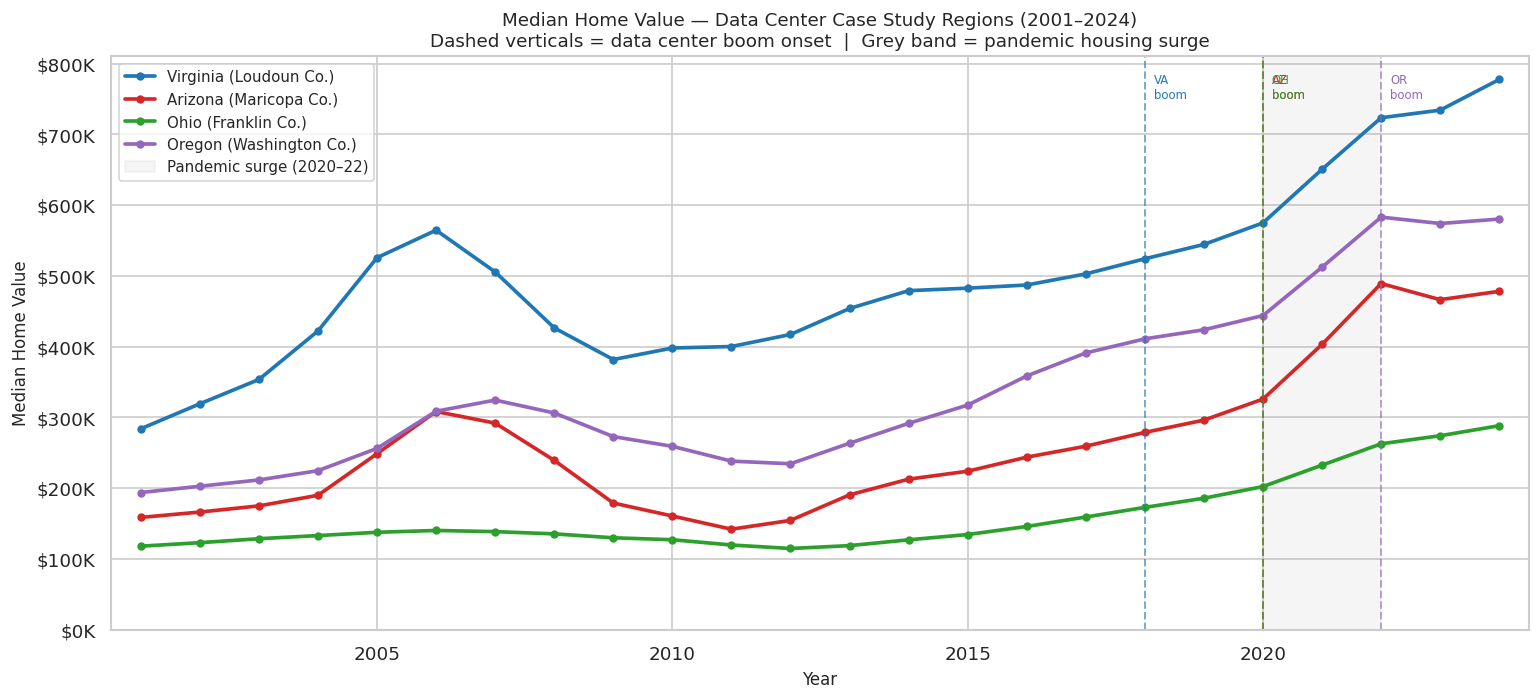

In [36]:
fig, ax = plt.subplots(figsize=(13, 6))

for abbr in STATE_ORDER:
    df = zhvi[zhvi['state_abbr'] == abbr].sort_values('Year')
    ax.plot(df['Year'], df['Home Value'] / 1e3, color=COLORS[abbr],
            lw=2.2, marker='o', ms=4, label=STATE_LABEL[abbr])

# Boom lines
for abbr in STATE_ORDER:
    ax.axvline(BOOM[abbr], color=COLORS[abbr], lw=1.2, ls='--', alpha=0.6)
    ax.text(BOOM[abbr] + 0.15, ax.get_ylim()[1] * 0.97,
            f'{abbr}\nboom', fontsize=7, color=COLORS[abbr], va='top')

# Shade 2020-2022 pandemic housing surge
ax.axvspan(2020, 2022, color='grey', alpha=0.08, label='Pandemic surge (2020–22)')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.set_xlim(2000.5, 2024.5)
ax.set_ylim(bottom=0)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Median Home Value', fontsize=10)
ax.set_title('Median Home Value — Data Center Case Study Regions (2001–2024)\n'
             'Dashed verticals = data center boom onset  |  Grey band = pandemic housing surge',
             fontsize=11)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig1_home_value.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Median monthly rent (2015–2024)

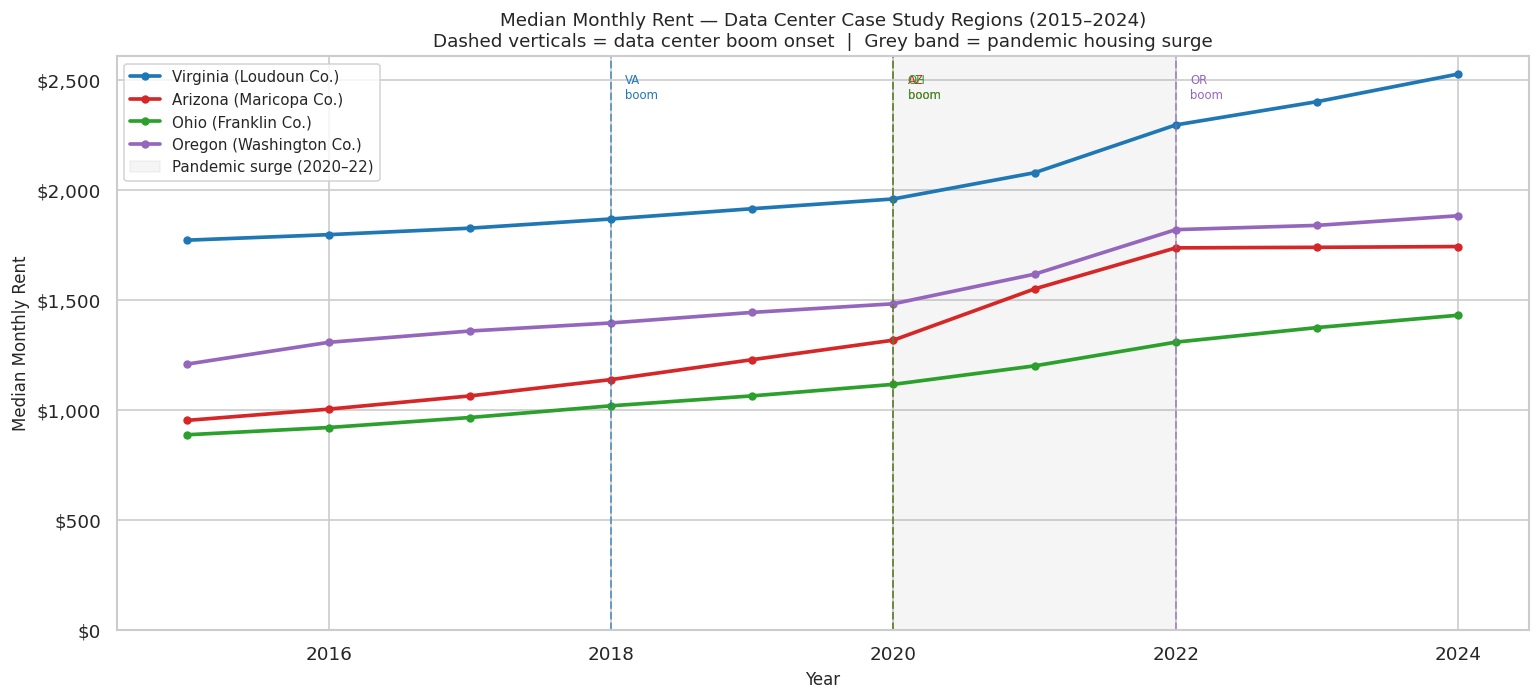

In [37]:
fig, ax = plt.subplots(figsize=(13, 6))

for abbr in STATE_ORDER:
    df = zori[zori['state_abbr'] == abbr].sort_values('Year')
    if df.empty:
        continue
    ax.plot(df['Year'], df['Rent'], color=COLORS[abbr],
            lw=2.2, marker='o', ms=4, label=STATE_LABEL[abbr])

# Boom lines
for abbr in STATE_ORDER:
    if BOOM[abbr] >= zori['Year'].min():
        ax.axvline(BOOM[abbr], color=COLORS[abbr], lw=1.2, ls='--', alpha=0.6)
        ax.text(BOOM[abbr] + 0.1, ax.get_ylim()[1] * 0.97,
                f'{abbr}\nboom', fontsize=7, color=COLORS[abbr], va='top')

ax.axvspan(2020, 2022, color='grey', alpha=0.08, label='Pandemic surge (2020–22)')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(2014.5, 2024.5)
ax.set_ylim(bottom=0)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Median Monthly Rent', fontsize=10)
ax.set_title('Median Monthly Rent — Data Center Case Study Regions (2015–2024)\n'
             'Dashed verticals = data center boom onset  |  Grey band = pandemic housing surge',
             fontsize=11)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig2_rent.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Year-over-year home value growth — heatmap

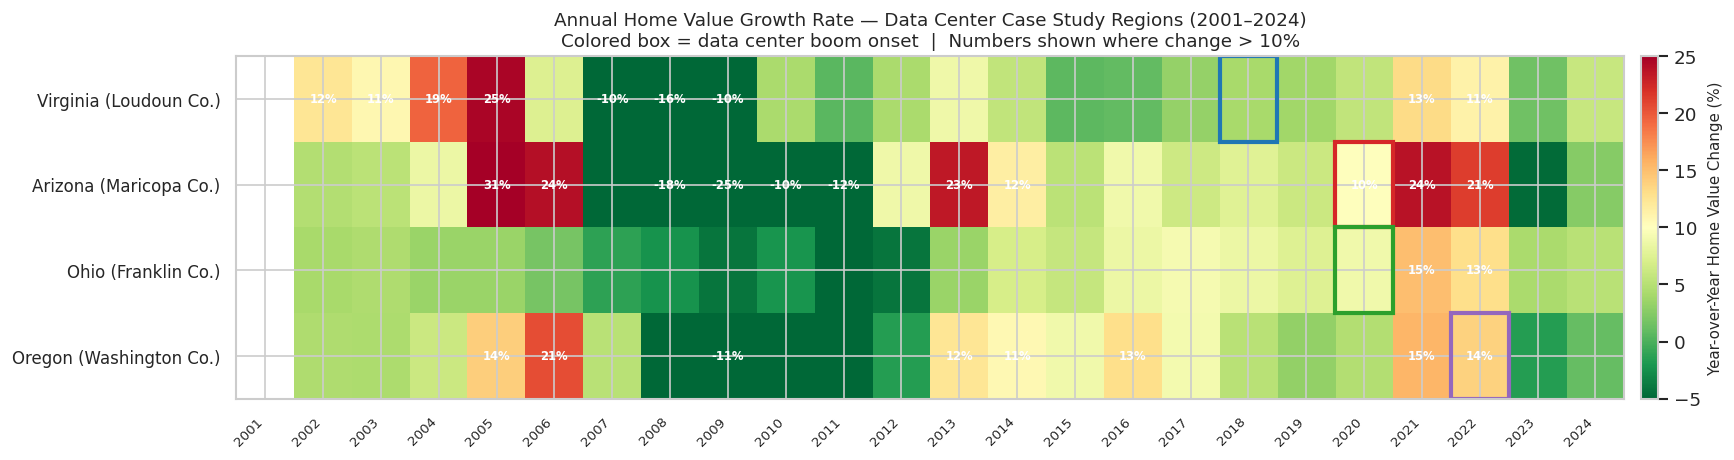

In [38]:
pivot = zhvi_yoy.pivot(index='state_abbr', columns='Year', values='YoY Change (%)')
pivot = pivot.loc[STATE_ORDER]
row_labels = [STATE_LABEL[s] for s in STATE_ORDER]

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
               vmin=-5, vmax=25, interpolation='nearest')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns.astype(int), rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(4))
ax.set_yticklabels(row_labels, fontsize=10)

# Boom year boxes
for i, abbr in enumerate(STATE_ORDER):
    if BOOM[abbr] in pivot.columns:
        col_idx = list(pivot.columns).index(BOOM[abbr])
        ax.add_patch(plt.Rectangle((col_idx - 0.5, i - 0.5), 1, 1,
                                    fill=False, edgecolor=COLORS[abbr], lw=2.5))

# Annotate cells where growth > 10%
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val) and abs(val) > 10:
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')

cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label('Year-over-Year Home Value Change (%)', fontsize=9)
ax.set_title("Annual Home Value Growth Rate — Data Center Case Study Regions (2001–2024)\n"
             "Colored box = data center boom onset  |  Numbers shown where change > 10%",
             fontsize=11)
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig3_home_value_growth_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()